# Deep Learning modeller
Her tænkes at afprøve hvorvidt deeplearning modeller kører for keyword spotting. Ved undersøgelse af modeller er der stødt på CNN, DS-CNN eller simpel MLP-NN modeller. Der bruges mfcc, mel og simple features som inputs og ikke rå lydfiler og sammenligner features, for at se hvilke fungerer bedst. Siden der 

Koden nedenfor er funktioner til at læse lydfiler, udregne mel, mfcc, frekvens og lignende, der bruges som features.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
FFT_N = 4096
N_MELS = 20
N_MFCC = 13
EPS = 1e-12

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak
    return x

def prepare_fft_frame(x: np.ndarray, fft_n: int = FFT_N) -> np.ndarray:
    frame = np.zeros(fft_n, dtype=np.float32)
    copy_len = min(len(x), fft_n)
    frame[:copy_len] = x[:copy_len]

    window = np.hanning(fft_n).astype(np.float32)
    frame *= window
    return frame

def magnitude_spectrum(x, fs, fft_n: int = FFT_N):
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, mag

def fft_real_only_power_emlearn_style(x, fs, fft_n: int = FFT_N):
    """
    Matcher eml_audio_power_spectrogram():
    bruger kun realdel af FFT-output og skalerer med 1/n_fft
    """
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(fft_n)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, power

def hz_to_mel(hz: float) -> float:
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels: float) -> float:
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n: int, n_mels: int, fmin: float, fmax: float) -> float:
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    mel = melmin + (n * melstep)
    return mel_to_hz(mel)

def eml_audio_mel_bin(hz: float, n_fft: int, samplerate: float) -> int:
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k: int, n_fft: int, samplerate: float) -> float:
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N):
    _, spec = fft_real_only_power_emlearn_style(x, fs, fft_n=fft_n)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + fft_n // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = eml_audio_mel_bin(left_hz, fft_n, fs)
        center = eml_audio_mel_bin(center_hz, fft_n, fs)
        right = eml_audio_mel_bin(right_hz, fft_n, fs)

        left = max(0, min(left, max_bin - 1))
        center = max(0, min(center, max_bin - 1))
        right = max(0, min(right, max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, fft_n, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += spec[k] * weight

        for k in range(center, right):
            if k + 1 >= len(spec):
                break
            r = right_hz - eml_fft_freq(k + 1, fft_n, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += spec[k + 1] * weight

        mels[m - 1] = val

    return mels

def dct_type_2(x: np.ndarray, n_out: int) -> np.ndarray:
    n = len(x)
    out = np.zeros(n_out, dtype=np.float32)
    for k in range(n_out):
        s = 0.0
        for m in range(n):
            s += x[m] * np.cos(np.pi * k * (m + 0.5) / n)
        out[k] = s
    return out

def mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N):
    mel = mel_spectrum_emlearn_style(x, fs, n_mels=n_mels, fft_n=fft_n)
    log_mel = np.log(mel + EPS)
    mfcc = dct_type_2(log_mel, n_mfcc)
    return mfcc.astype(np.float32)

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mel_vals = mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    mfcc_vals = mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES

train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)
# =========================


# =========================
# FEATURE SETS
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mel_feature_cols = [f"mel_{i}" for i in range(1, N_MELS + 1)]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "mel": mel_feature_cols,
    "Simplefeat_mfcc": mfcc_feature_cols + simple_features,
    "combined": simple_features + mfcc_feature_cols + mel_feature_cols,
}
# =========================



c:\ProgramData\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## MLP neural netværk
Siden vi har tabular mfcc bruges MLP neural netværk, og observere hvor vel den kan klassificere ordene. MLP structuren der er brugt her ser således ud:

input( input dimension (baseret på hvilken feature der brugt))

Dense(128) --> ReLU --> Dense(64) --> ReLU --> Dense(32) --> ReLU --> Dense(16) --> ReLU --> Dense(6, activation=sigmoid)

In [2]:
from sklearn.model_selection import train_test_split

MODEL_EPOCHS = 10000
MODEL_PATIENCE = 300
BATCH_SIZE = 32

# =========================
# Choosing feature to train and test from
feat_name = "simple"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# =========================

print(X_train.shape)
print(X_test.shape)

(600, 9)
(140, 9)


In [3]:
model_simpleFeatures = models.Sequential([
    layers.Input(shape=(9,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_simpleFeatures.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,350 (13.09 KB)

 Trainable params: 3,350 (13.09 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_simpleFeatures.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_simpleFeatures.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_simpleFeatures.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================


    

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1017 - loss: 4207.2500 - val_accuracy: 0.1357 - val_loss: 3743.6130
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1000 - loss: 3051.7021 - val_accuracy: 0.1357 - val_loss: 2457.0354
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1050 - loss: 2009.0754 - val_accuracy: 0.1286 - val_loss: 1493.9674
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1133 - loss: 1183.9009 - val_accuracy: 0.1714 - val_loss: 646.1710
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2500 - loss: 796.6753 - val_accuracy: 0.3571 - val_loss: 478.1003
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2700 - loss: 695.5157 - val_accuracy: 0.3500 - val_loss: 398.4123
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2800 - loss: 607.0205 - val_accuracy: 0.3714 - val_loss: 340.8312
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accura

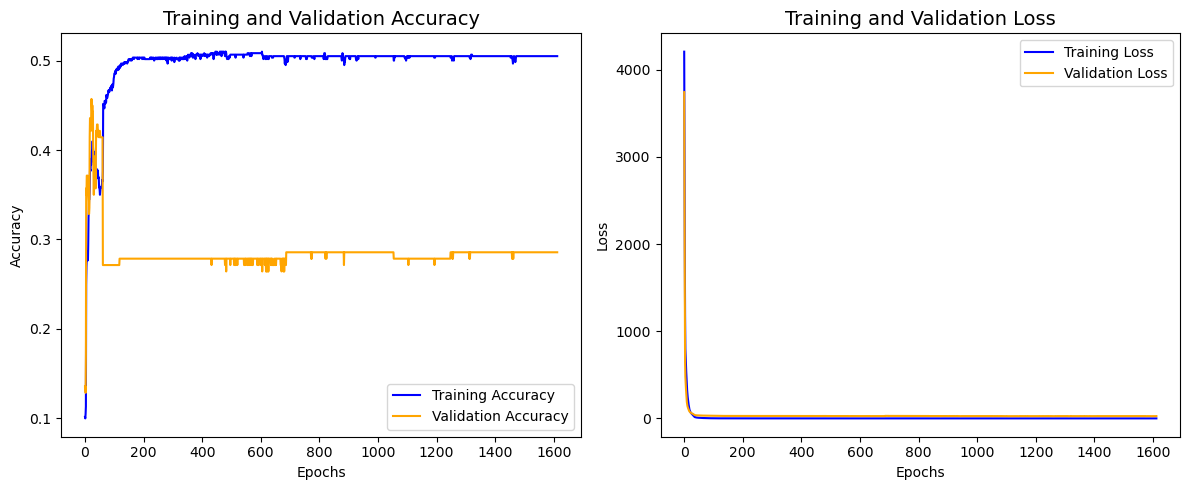

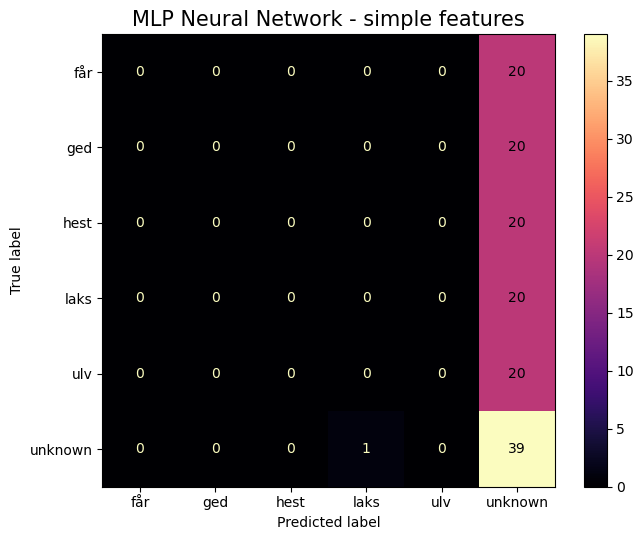

Accuracy: 0.279


In [5]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - simple features",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

ved at bruge de simple features, gav ikke nogen resultater og klassificerede en del forkerte og learning kurve viser at modellen hurtigt overfitter. Dette er features der ikke indeholder nok information til at kunne klassificere keywords. Nu forsøges der med MFCC:

In [6]:
# =========================
# Choosing feature to train and test from
feat_name = "mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# =========================

print(X_train.shape)
print(X_test.shape)


(600, 13)
(140, 13)


In [7]:
model_mfcc = models.Sequential([
    layers.Input(shape=(13,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),
    
    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mfcc.summary()
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mfcc.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mfcc.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mfcc.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,606 (14.09 KB)

 Trainable params: 3,606 (14.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1117 - loss: 10.9090 - val_accuracy: 0.1571 - val_loss: 9.4911
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1050 - loss: 8.6923 - val_accuracy: 0.1571 - val_loss: 7.8498
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1067 - loss: 6.6355 - val_accuracy: 0.1214 - val_loss: 6.4958
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1400 - loss: 4.9747 - val_accuracy: 0.0286 - val_loss: 5.7182
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2083 - loss: 4.0045 - val_accuracy: 0.0357 - val_loss: 4.8541
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2267 - loss: 3.0880 - val_accuracy: 0.0429 - val_loss: 3.5149
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2417 - loss: 2.2981 - val_accuracy: 0.1071 - val_loss: 2.6207
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2933 - loss: 1.8734 - val_ac

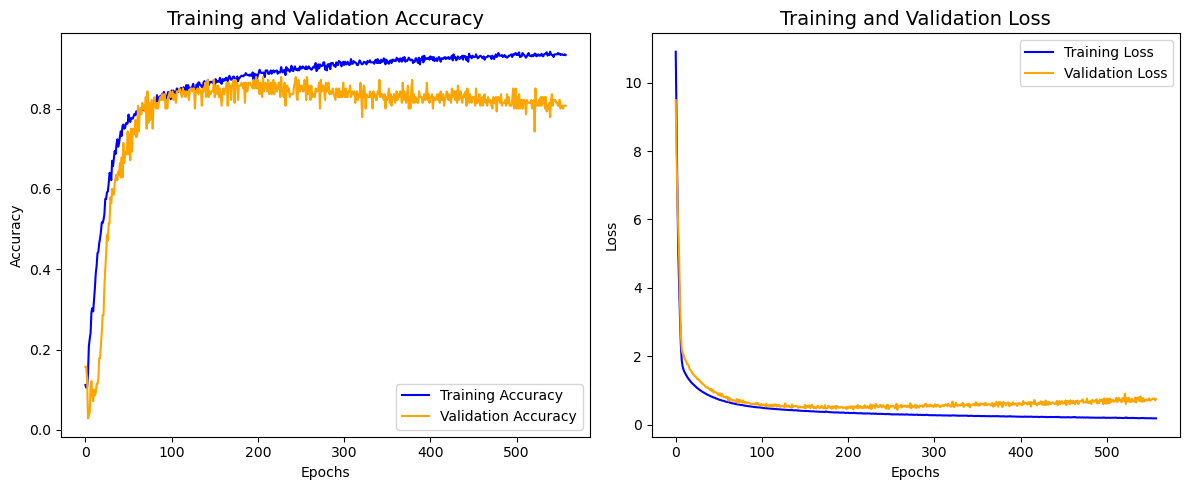

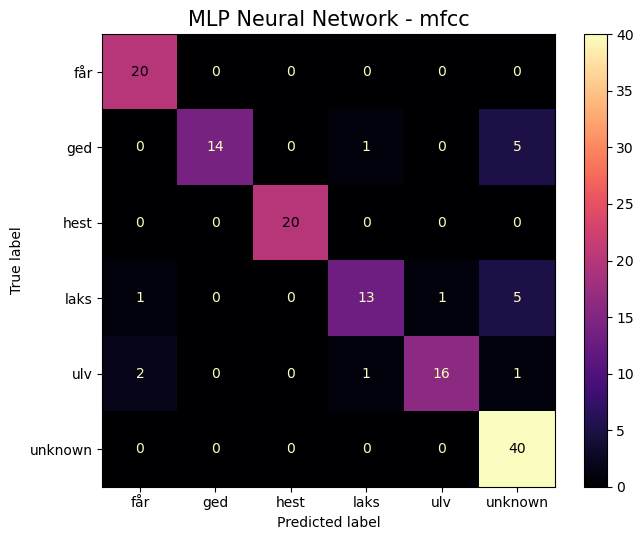

Accuracy: 0.879


In [8]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - mfcc",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Med MFCC fås et bedre accuracy, og viser samme tegn, som med simple features, og viser potentiale for at den finder mønster på MFCC resultatet. Vi forsøger nu med mel.

In [9]:
# =========================
# Choosing feature to train and test from
feat_name = "mel"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# =========================
print(X_train.shape)
print(X_test.shape)


(600, 20)
(140, 20)


In [10]:
model_mel = models.Sequential([
    layers.Input(shape=(20,)),

    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mel.summary()

early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mel.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mel.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mel.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054 (15.84 KB)

 Trainable params: 4,054 (15.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1733 - loss: 1.8398 - val_accuracy: 0.0429 - val_loss: 1.7737
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2250 - loss: 1.8010 - val_accuracy: 0.0214 - val_loss: 1.7231
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2617 - loss: 1.7646 - val_accuracy: 0.1429 - val_loss: 1.6807
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3467 - loss: 1.7281 - val_accuracy: 0.2214 - val_loss: 1.6444
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4033 - loss: 1.6944 - val_accuracy: 0.2500 - val_loss: 1.6086
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4317 - loss: 1.6603 - val_accuracy: 0.2714 - val_loss: 1.5787
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4667 - loss: 1.6305 - val_accuracy: 0.2857 - val_loss: 1.5528
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4933 - loss: 1.6035 - val_acc

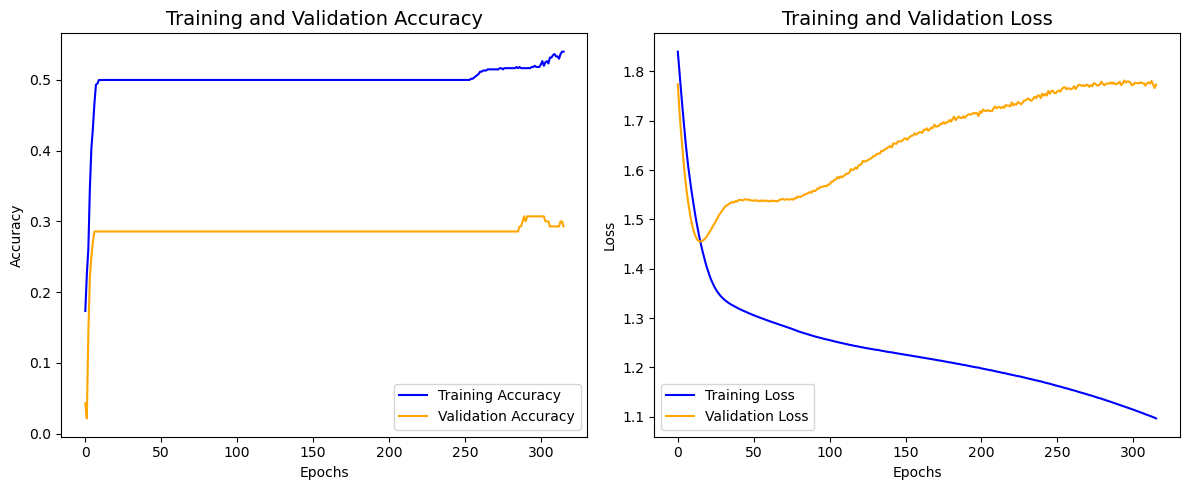

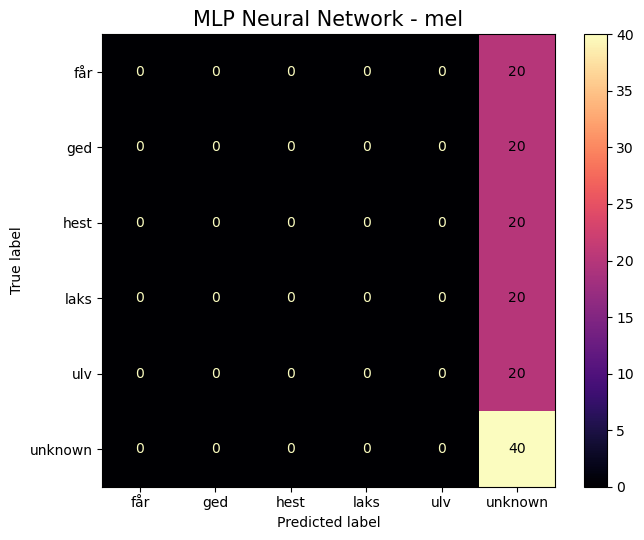

Accuracy: 0.286


In [11]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - mel",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Det ses at med MEL, klassificerer modellen alle inputs som "unknown" og fungerer på ingen måde som den bedste feature at bruge. Vi forsøger nu med at kombinerer simple features og MFCC features, og ser hvilken effekt det vil have for modellen, om den kan finde mønstrene fra begge features og blive bedre.

In [12]:
# =========================
# Choosing feature to train and test from
feat_name = "Simplefeat_mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# =========================
print(X_train.shape)
print(X_test.shape)



(600, 22)
(140, 22)


In [13]:
model_mfcc_simplefeat = models.Sequential([
    layers.Input(shape=(22,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mfcc_simplefeat.summary()

early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mfcc_simplefeat.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mfcc_simplefeat.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mfcc_simplefeat.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,182 (16.34 KB)

 Trainable params: 4,182 (16.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1000 - loss: 4800.7964 - val_accuracy: 0.1429 - val_loss: 5523.1890
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1000 - loss: 3867.0400 - val_accuracy: 0.1500 - val_loss: 4424.4351
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1067 - loss: 3075.0959 - val_accuracy: 0.1571 - val_loss: 3281.4536
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1133 - loss: 2297.6228 - val_accuracy: 0.1714 - val_loss: 2446.1990
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1217 - loss: 1664.5494 - val_accuracy: 0.1714 - val_loss: 1597.2456
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1383 - loss: 1060.8821 - val_accuracy: 0.1786 - val_loss: 985.6728
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1733 - loss: 578.1877 - val_accuracy: 0.2143 - val_loss: 424.9270
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - ac

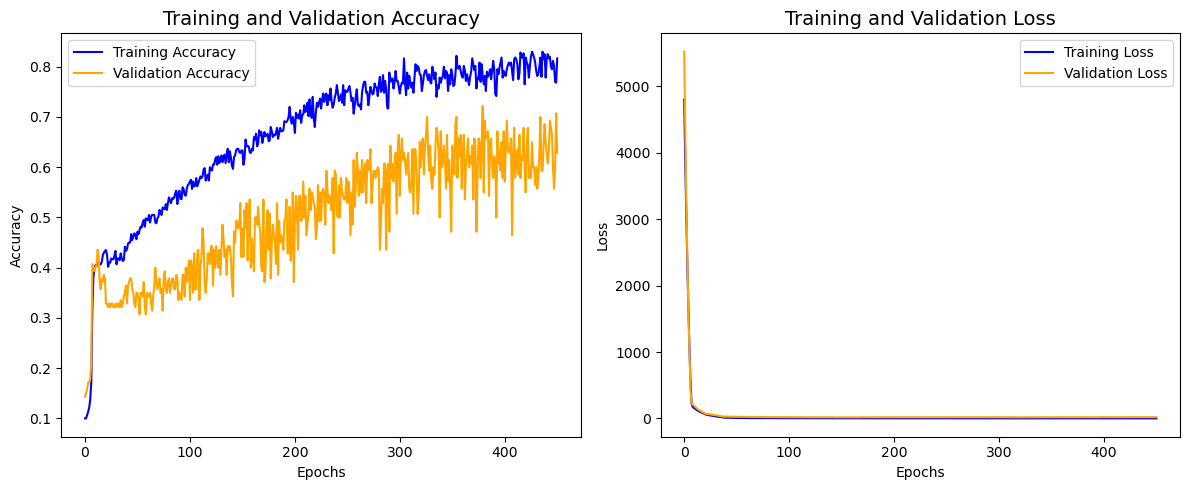

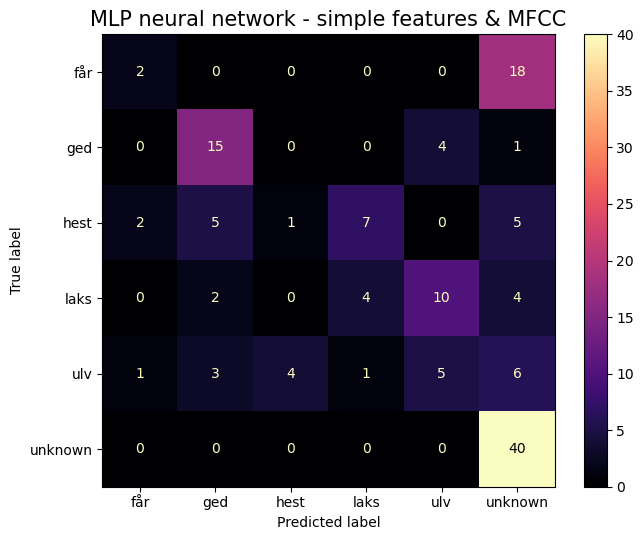

Accuracy: 0.479


In [14]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP neural network - simple features & MFCC",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Det ses det ikke gav et bedre resultat. Der testes nu med alle features kombineret og tjekker resultatet af confusion matricen.

In [15]:
# =========================
# Choosing feature to train and test from
feat_name = "combined"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
# =========================

print(X_train.shape)
print(X_test.shape)


(600, 42)
(140, 42)


In [16]:
model_allfeat = models.Sequential([
    layers.Input(shape=(42,)),

    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_allfeat.summary()

early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_allfeat.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_allfeat.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)
# =========================
# PREDICT
y_prob = model_allfeat.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,462 (21.34 KB)

 Trainable params: 5,462 (21.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1000 - loss: 4454.8364 - val_accuracy: 0.1000 - val_loss: 4710.1270
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1267 - loss: 3882.2849 - val_accuracy: 0.1429 - val_loss: 4059.4338
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1350 - loss: 3349.4866 - val_accuracy: 0.1429 - val_loss: 3510.0508
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1300 - loss: 2849.9661 - val_accuracy: 0.1143 - val_loss: 2864.9529
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1267 - loss: 2344.9763 - val_accuracy: 0.0786 - val_loss: 2189.2295
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1300 - loss: 1775.5981 - val_accuracy: 0.1500 - val_loss: 1554.7659
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1300 - loss: 1279.3363 - val_accuracy: 0.1714 - val_loss: 954.2788
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

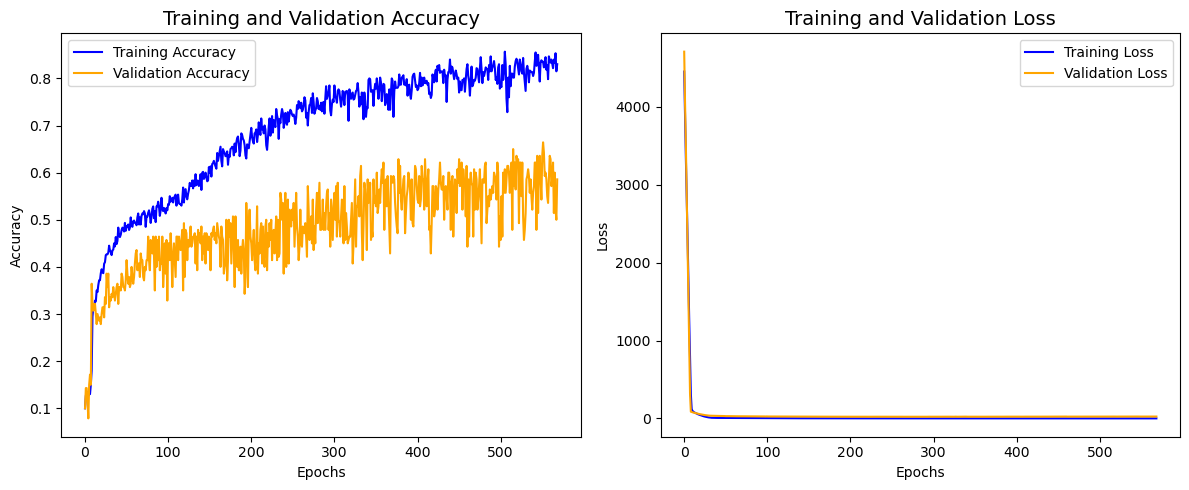

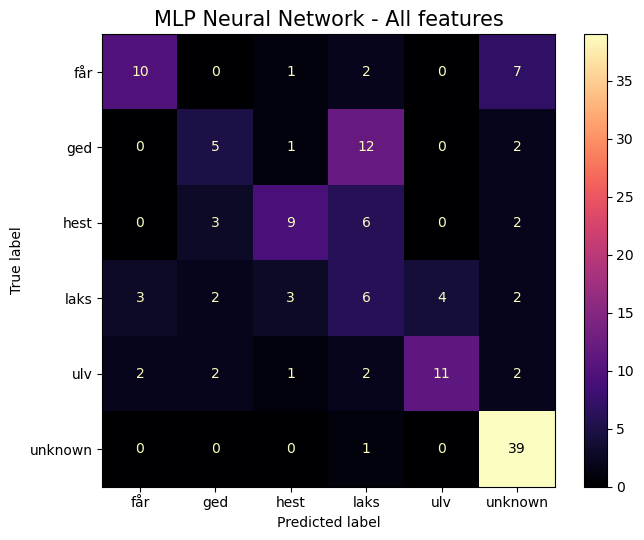

Accuracy: 0.571


In [17]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - All features",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

In [18]:
#model_mfcc.save('MFCC_KWS_MLP_Model.h5')
#model_mfcc.save('MFCC_KWS_MLP_Model.keras')

Det ses tydeligt at ved brug af MFCC feature alene, som input for modellen, giver den højeste accuracy og vælger at bruge den fremover. Der eksisterer andre modeller til keyword spotting der er bedre end MLP modellen, såsom convolution neural network.

## Convolutional Neural Network (CNN)
Efter at have undersøgt om keyword spotting, er det tænkt at implementere DS-CNN, da den er en mere effektiv alternativ til CNN (https://link.springer.com/article/10.1186/s13636-020-00176-2). Men da det er tænkt at bruge AIfES til at implementere modellen i C kode til mikrokontrolleren, er det ikke muligt at implementere den, da AIfES blandt andre funktioner ikke har "depthwiseConv2D" lag implementeret. Det vælges derfor at implementere en simpel CNN model.

Her kan vi forsøge at teste med CNN og DS-CNN, for at teste hvilke forskelle det kan have at teste med udregne MFCC over flere frames og ikke over hele lydfilen. Dette er mere udregningsmæssigt dyrer, men giver mere information, såsom tid og frekvens, hvordan lyden evolverer over tid. Dette giver også en 2D feature map.

In [36]:
# =========================
# MFCC SPECTROGRAM

FRAME_LENGTH = 400      # 25 ms at 16kHz
FRAME_STEP = 160        # 10 ms hop
N_MELS = 20
N_MFCC = 20

def frame_signal(x, frame_length=FRAME_LENGTH, frame_step=FRAME_STEP):
    frames = []

    for start in range(0, len(x) - frame_length + 1, frame_step):
        frame = x[start:start + frame_length]
        frames.append(frame)

    return np.array(frames, dtype=np.float32)


def mfcc_spectrogram(
    x,
    fs,
    frame_length=FRAME_LENGTH,
    frame_step=FRAME_STEP,
    n_mfcc=N_MFCC,
    n_mels=N_MELS,
    fft_n=4092
):
    frames = frame_signal(
        x,
        frame_length=frame_length,
        frame_step=frame_step
    )

    spec = []

    for frame in frames:

        mfcc = mfcc_features_emlearn_style(
            frame,
            fs,
            n_mfcc=n_mfcc,
            n_mels=n_mels,
            fft_n=fft_n
        )

        spec.append(mfcc)

    spec = np.array(spec, dtype=np.float32)

    return spec

# =========================

Modellen vi bruger er:

```python

CNN_Model = models.Sequential([
    layers.Input(shape=(98, 16, 1)),
    layers.Conv2D( 8, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D( 16, (3,3), activation='relu', padding='same' ),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(ALL_LABELS), activation='softmax')
])


Vi træner og tester med samme eller lignende parametre, som brugt tidligere.

In [37]:
X_test = []
y_test = []
X_train = []
y_train = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        X_train.append(mfcc_spectrogram(x, SAMPLE_RATE))
        y_train.append(label)


for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    X_train.append(mfcc_spectrogram(x, SAMPLE_RATE))
    y_train.append("unknown")

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        X_test.append(mfcc_spectrogram(x, SAMPLE_RATE))
        y_test.append(label)


X_train = np.array(X_train, dtype=np.float32)
X_train = X_train[..., np.newaxis]

X_test = np.array(X_test, dtype=np.float32)
X_test = X_test[..., np.newaxis]

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


print(X_test.shape)
print(y_test.shape)

(140, 98, 20, 1)
(140,)


In [72]:

CNN_Model = models.Sequential([
    layers.Input(shape=(98, 20, 1)),
    layers.Conv2D( 8, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D( 16, (3,3), padding='same' ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(32,),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dense(16),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dense(len(ALL_LABELS), activation='softmax')
])

CNN_Model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 98, 20, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 98, 20, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_68 (ReLU)                 │ (None, 98, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 49, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 49, 10, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 49, 10, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_69 (ReLU)                 │ (None, 49, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 24, 5, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 32)             │        61,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_70 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_71 (ReLU)                 │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,638 (248.59 KB)

 Trainable params: 63,494 (248.02 KB)

 Non-trainable params: 144 (576.00 B)

In [73]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

CNN_Model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = CNN_Model.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)



Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.3767 - loss: 1.4948 - val_accuracy: 0.1429 - val_loss: 4.1867
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7450 - loss: 0.9574 - val_accuracy: 0.2857 - val_loss: 2.5512
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8967 - loss: 0.7133 - val_accuracy: 0.2857 - val_loss: 2.2548
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9617 - loss: 0.5551 - val_accuracy: 0.2929 - val_loss: 1.8817
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9817 - loss: 0.4658 - val_accuracy: 0.4071 - val_loss: 1.3930
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9950 - loss: 0.3604 - val_accuracy: 0.7357 - val_loss: 1.2407
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9983 - loss: 0.3009 - val_accuracy: 0.7571 - val_loss: 1.1408
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9983 - loss: 0.2549 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


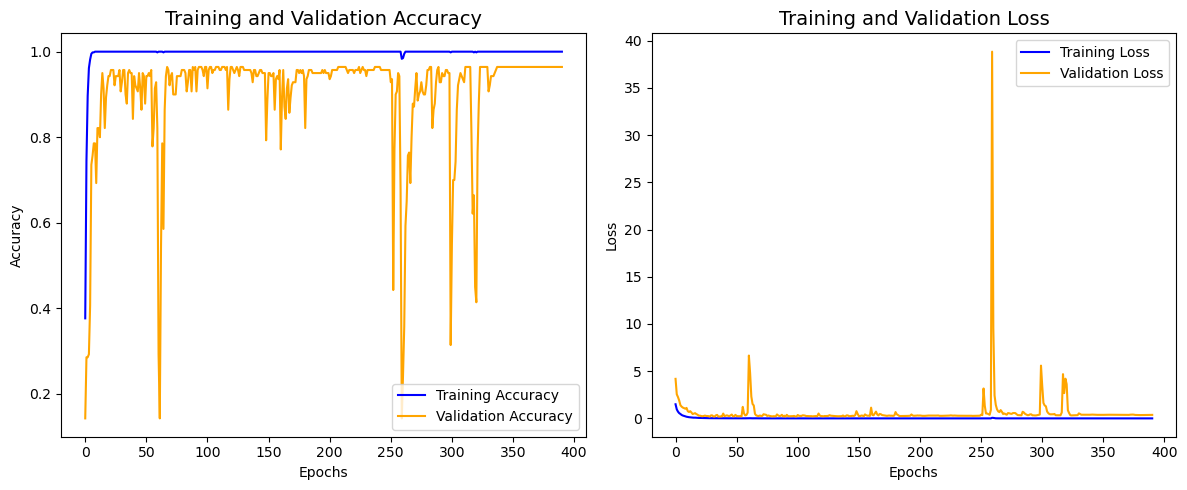

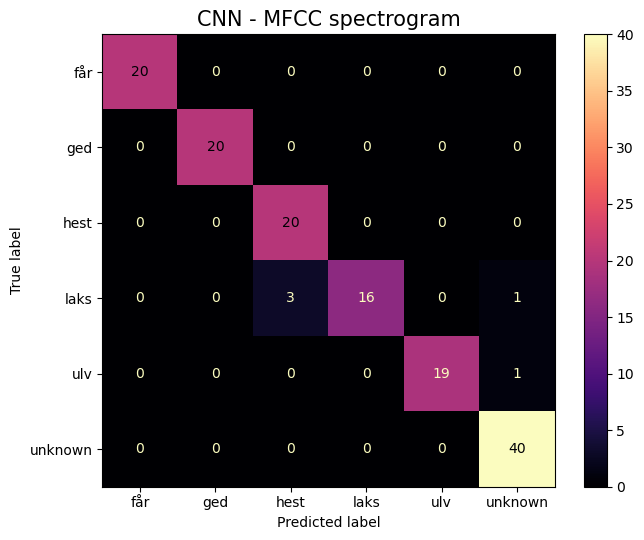

Accuracy: 0.964


In [74]:

# =========================
# PREDICT
y_prob = CNN_Model.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test_enc
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred_idx)
# =========================

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX


cm = confusion_matrix(y_test_enc, y_pred_idx)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"CNN - MFCC spectrogram",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Her observeres at modellen har en god accuracy, bedre end MLP-NN. vi vælger at bruge denne model til implementering på vores processor.

In [24]:
#CNN_Model.save('MFCC_KWS_CNN_Model.h5')
#CNN_Model.save('MFCC_KWS_CNN_Model.keras')

Her testes DS-CNN, selvom den ikke kan implementeres i AIfES, og ser hvorvidt den klare sig i forhold til CNN modellen fra tidligere.

In [78]:
DS_CNN_model = models.Sequential([

    layers.Input(shape=(98, 20, 1)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        use_bias=True
    ),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.DepthwiseConv2D(
        (3,3),
        padding='same',
        use_bias=True
    ),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Conv2D(
        32,
        (1,1),
        padding='same',
        use_bias=True
    ),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.MaxPooling2D((2,2)),

    layers.DepthwiseConv2D(
        (3,3),
        padding='same',
        use_bias=True
    ),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Conv2D(
        16,
        (1,1),
        padding='same',
        use_bias=True
    ),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),


    layers.Dense(len(ALL_LABELS), activation='softmax')
])

DS_CNN_model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 98, 20, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 98, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_79 (ReLU)                 │ (None, 98, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_22             │ (None, 98, 20, 64)     │           640 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 98, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_80 (ReLU)                 │ (None, 98, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 98, 20, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 98, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_81 (ReLU)                 │ (None, 98, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 49, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_23             │ (None, 49, 10, 32)     │           320 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 49, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_82 (ReLU)                 │ (None, 49, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 49, 10, 16)     │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 49, 10, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_83 (ReLU)                 │ (None, 49, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 24, 5, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 6)              │           10

 Total params: 6,214 (24.27 KB)

 Trainable params: 5,798 (22.65 KB)

 Non-trainable params: 416 (1.62 KB)

In [79]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

DS_CNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = DS_CNN_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)



Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.2000 - loss: 1.7308 - val_accuracy: 0.2857 - val_loss: 1.7820
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.5000 - loss: 1.5423 - val_accuracy: 0.2857 - val_loss: 1.7738
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.5083 - loss: 1.3533 - val_accuracy: 0.2857 - val_loss: 1.7673
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5583 - loss: 1.2103 - val_accuracy: 0.2857 - val_loss: 1.7634
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.6617 - loss: 1.0374 - val_accuracy: 0.2857 - val_loss: 1.7604
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.7167 - loss: 0.9009 - val_accuracy: 0.2857 - val_loss: 1.7535
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.7600 - loss: 0.7723 - val_accuracy: 0.2857 - val_loss: 1.7604
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.7750 - loss: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


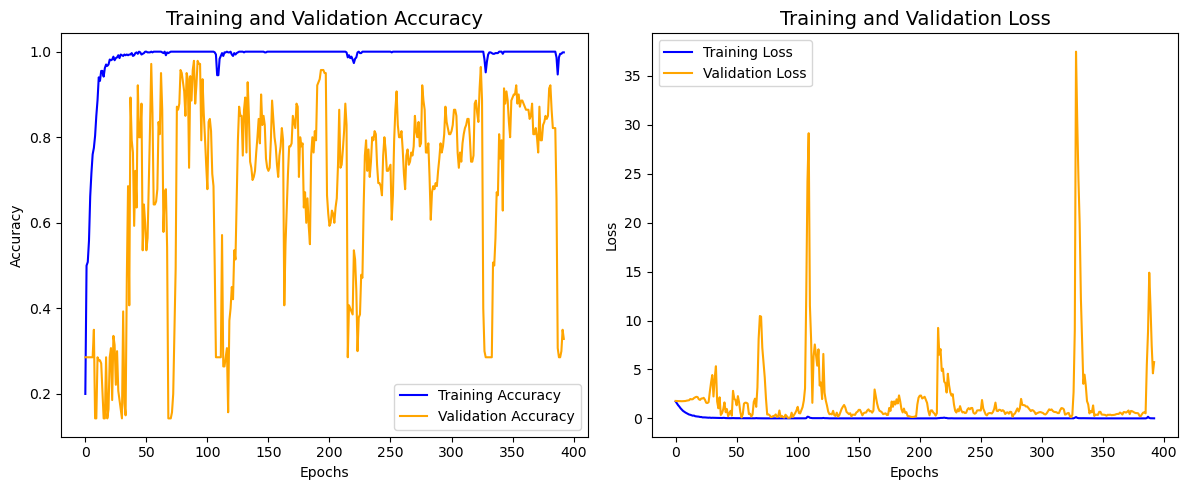

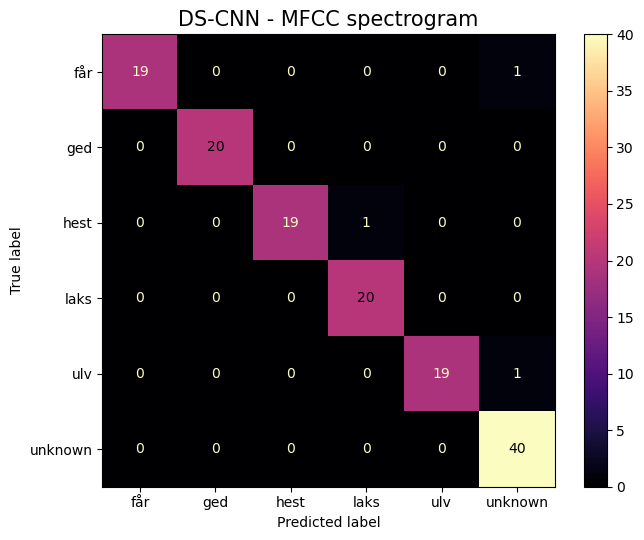

Accuracy: 0.979


In [80]:

# =========================
# PREDICT
y_prob = DS_CNN_model.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test_enc
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred_idx)
# =========================

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX


cm = confusion_matrix(y_test_enc, y_pred_idx)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"DS-CNN - MFCC spectrogram",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Vi tester også med MFCC, brugt til MLP-NN og ser hvordan CNN med conv1D lag, kører i forhold til MLP-NN

In [28]:
# =========================
# Choosing feature to train and test from
feat_name = "mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# =========================


print(X_train.shape)
print(X_test.shape)

(600, 13)
(140, 13)


In [29]:

CNN_model = models.Sequential([
    layers.Input(shape=(16, 1)),
    layers.Conv1D(32, 3, activation="relu"),
    layers.MaxPool1D(),
    layers.Conv1D(64, 3, activation="relu"),
    layers.GlobalMaxPool1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(ALL_LABELS), activation="softmax")
])

CNN_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 14, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,886 (42.52 KB)

 Trainable params: 10,886 (42.52 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

CNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = CNN_model.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1117 - loss: 2.7913 - val_accuracy: 0.0357 - val_loss: 2.6046
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4433 - loss: 1.8501 - val_accuracy: 0.2857 - val_loss: 2.1486
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4800 - loss: 1.5335 - val_accuracy: 0.2857 - val_loss: 1.7352
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4950 - loss: 1.3554 - val_accuracy: 0.2857 - val_loss: 1.6335
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 1.2572 - val_accuracy: 0.2929 - val_loss: 1.5193
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5233 - loss: 1.1809 - val_accuracy: 0.3214 - val_loss: 1.4291
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5467 - loss: 1.1201 - val_accuracy: 0.3500 - val_loss: 1.3515
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5650 - loss: 1.0718 - val_acc

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


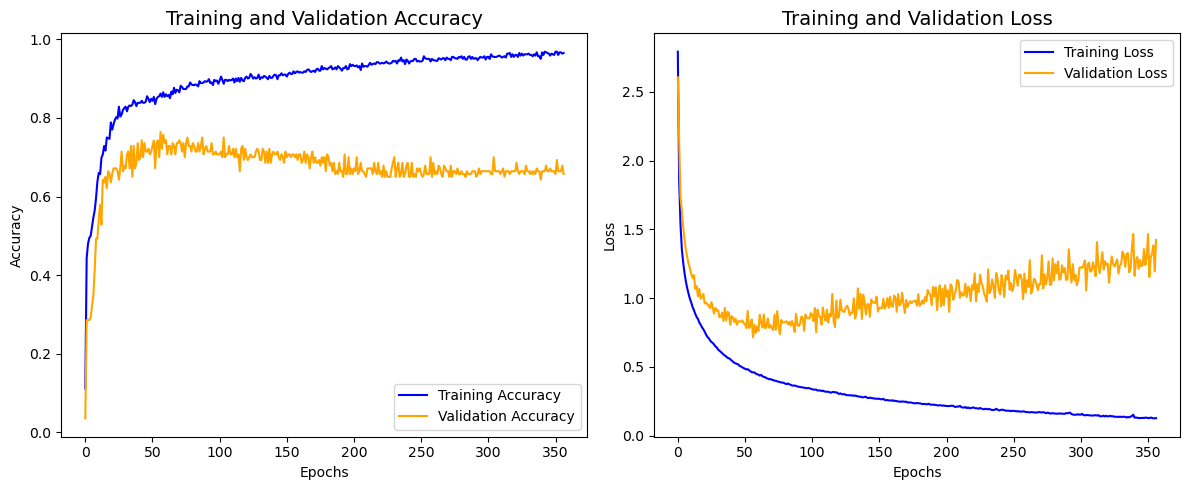

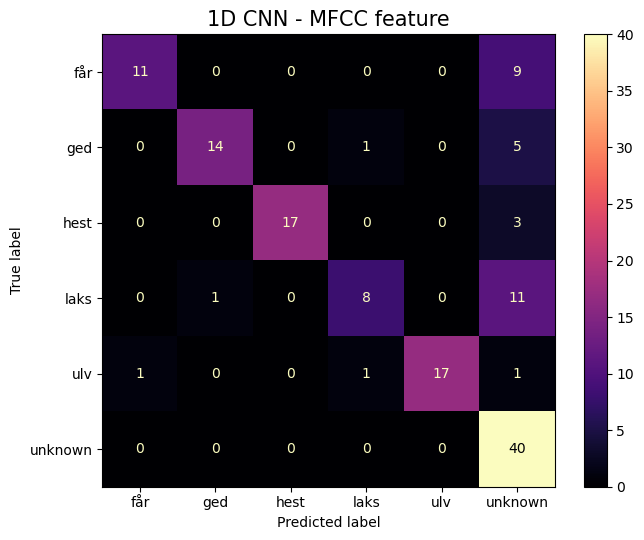

Accuracy: 0.764


In [31]:
# =========================
# PREDICT
y_prob = CNN_model.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test_enc
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred_idx)
# =========================

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX


cm = confusion_matrix(y_test_enc, y_pred_idx)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"1D CNN - MFCC feature",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

før vi kan implementere modellen i AIfES skal vi bruge vægtene i lagene fra den trænet model.

In [32]:
import tensorflow as tf
final_model = tf.keras.models.load_model('final models/MFCC_KWS_CNN_Model.keras')
final_model.summary()

for i, layer in enumerate(final_model.layers):
    try:
        w = layer.get_weights()
        print(i, layer.name, "WEIGHTS")
    except:
        print(i, layer.name, "NO WEIGHTS")

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 16, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 8, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 49, 8, 16)      │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 4, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │        49,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,262 (395.56 KB)

 Trainable params: 50,630 (197.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,632 (197.79 KB)

0 conv2d WEIGHTS
1 max_pooling2d WEIGHTS
2 conv2d_1 WEIGHTS
3 max_pooling2d_1 WEIGHTS
4 flatten WEIGHTS
5 dense_20 WEIGHTS
6 dense_21 WEIGHTS


In [33]:
for layer in final_model.layers:

    weights = layer.get_weights()

    if len(weights) == 0:
        continue

    print("\n====================")
    print("Layer:", layer.name)
    print("====================")

    for i, w in enumerate(weights):
        print(f"\nTensor {i}:")
        print(w)


Layer: conv2d

Tensor 0:
[[[[ 0.08811681 -0.0113709  -0.00988541 -0.2571507   0.09368221
    -0.10292629 -0.08328941  0.18747066]]

  [[-0.19684997  0.04844759 -0.19811347  0.19042595  0.15163542
     0.03820571  0.16977721 -0.07631238]]

  [[ 0.2581656   0.00781089 -0.2629936  -0.03673561  0.11758373
     0.0618127   0.154115    0.17461683]]]


 [[[ 0.15088856  0.25908744 -0.17730072 -0.19019811 -0.04016878
     0.21524467  0.0076945  -0.20997879]]

  [[-0.16141565  0.23312192  0.10508745  0.0656386   0.17405029
    -0.05377956  0.12758501  0.12038632]]

  [[ 0.20805387 -0.2737748  -0.24422798 -0.2505931  -0.00063633
     0.0387416  -0.21175066 -0.16675797]]]


 [[[-0.04971161 -0.12098378 -0.10823493 -0.20900154 -0.14841491
    -0.23162402 -0.12179782  0.19353344]]

  [[-0.08698877 -0.19580589 -0.05207712 -0.04717768  0.23729336
     0.29981273 -0.25653148  0.21133742]]

  [[ 0.20357782 -0.04874254 -0.15243499  0.03404927  0.10244459
     0.05946149  0.27599806 -0.1682781 ]]]]

Tenso

Vi har haft nogle problemer med at implementere CNN modellen, men har haft succes med MLP-NN modellen, på grund af compileringsfejl. Tradeoff er at MLP-NN har en accuracy på 0.85, mens CNN modellen har en på 0.95, tilgængeld er der den hurtigere, da der ikke udregnes FFT flere gange og modellen er mindre. Vi henter weights oh bias for MLP-modellen til implementeringen af modellen.

In [34]:
import tensorflow as tf
final_model = tf.keras.models.load_model('final models/MFCC_KWS_MLP_Model.keras')
final_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,598 (29.68 KB)

 Trainable params: 3,798 (14.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,800 (14.85 KB)

In [35]:
w1, b1 = final_model.layers[0].get_weights()  # first Dense layer
w2, b2 = final_model.layers[2].get_weights()  # second Dense layer
w3, b3 = final_model.layers[4].get_weights()  # third Dense layer
w4, b4 = final_model.layers[6].get_weights()  # fourth Dense layer

w1_flat = w1.flatten()
b1_flat = b1.flatten()

w2_flat = w2.flatten()
b2_flat = b2.flatten()

w3_flat = w3.flatten()
b3_flat = b3.flatten()

w4_flat = w4.flatten()
b4_flat = b4.flatten()


# 6) Print them as C arrays
print("/* Weights and biases for the first layer */")
print("float weights1[] = {")
for val in w1_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases1[] = {")
for val in b1_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the second layer */")
print("float weights2[] = {")
for val in w2_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases2[] = {")
for val in b2_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the third layer */")
print("float weights3[] = {")
for val in w3_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases3[] = {")
for val in b3_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the fourth layer */")
print("float weights4[] = {")
for val in w4_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases4[] = {")
for val in b4_flat:
    print(f"  {val:.6f}f,")
print("};")



/* Weights and biases for the first layer */
float weights1[] = {
  0.104954f,
  0.246319f,
  -0.260782f,
  -0.082965f,
  -0.120466f,
  0.107030f,
  -0.183328f,
  0.263895f,
  -0.252350f,
  0.092339f,
  -0.148123f,
  0.039312f,
  0.166535f,
  -0.227095f,
  0.177709f,
  -0.066650f,
  -0.153181f,
  -0.075491f,
  0.026840f,
  -0.263623f,
  -0.187690f,
  0.268159f,
  -0.054077f,
  0.202740f,
  -0.188527f,
  -0.175056f,
  -0.258592f,
  0.258930f,
  -0.087834f,
  0.197748f,
  0.053050f,
  0.234695f,
  -0.063815f,
  0.151482f,
  -0.186655f,
  0.221368f,
  0.055139f,
  -0.025819f,
  0.219898f,
  -0.265097f,
  -0.144509f,
  0.182421f,
  0.168932f,
  -0.253211f,
  0.206854f,
  0.216010f,
  -0.070481f,
  0.063935f,
  -0.131603f,
  -0.107477f,
  -0.163230f,
  0.132377f,
  0.197137f,
  0.262656f,
  -0.256178f,
  -0.222576f,
  -0.021311f,
  -0.200011f,
  0.204744f,
  -0.010809f,
  0.151700f,
  0.039000f,
  0.120796f,
  -0.130714f,
  -0.253289f,
  -0.000046f,
  -0.297317f,
  -0.103890f,
  0.085280f,


referencer

1. https://ieeexplore.ieee.org/abstract/document/10050122
2. https://ieeexplore.ieee.org/document/10136648

3. https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/

4. https://backend.orbit.dtu.dk/ws/portalfiles/portal/216372364/S_rensen_et_al_2020_EURASIP_Journal_on_Audio_Speech_and_Music_Processing.pdf

5. https://www.mdpi.com/2079-9292/12/18/3964 